# Workout video dataset — exploratory analysis

This notebook summarizes videos under:

- **Verified train sources:** `data/verified_data/verified_data/data_btc_10s` and `…/data_crawl_10s` (class folders, `.mp4` files)
- **Hold-out test:** `data/test/test` (same class layout as in `config.base_config.BaseConfig`)

It reports counts per class and source, duration / FPS / resolution distributions, and a few **sample clips** resized to short-side **≤ 320** with a small number of frames (same spirit as `scripts/visualize_flow.decode_rgb_frames`).

Run from the repo root, or any cwd — the first code cell fixes `sys.path` and `REPO_ROOT` like `analysis/analyze_videomae.ipynb`.

In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if (REPO_ROOT / "analysis").is_dir() and (REPO_ROOT / "utils").is_dir():
    pass
elif (REPO_ROOT.parent / "utils").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import os

from tqdm.contrib.concurrent import thread_map

from analysis.eda_dataset import (
    DEFAULT_PATHS,
    dataframe_row_from_record,
    decode_sample_frames,
    iter_video_records,
)

for name, p in DEFAULT_PATHS.items():
    print(f"{name}: {p}  exists={p.is_dir()}")

verified_btc: /Users/microowave/Documents/VScode/CMU/10701/workout-prediction/data/reencoded/data_btc_10s  exists=True
verified_crawl: /Users/microowave/Documents/VScode/CMU/10701/workout-prediction/data/reencoded/data_crawl_10s  exists=True
test: /Users/microowave/Documents/VScode/CMU/10701/workout-prediction/data/reencoded/test  exists=True


## Scan filesystem & probe metadata

Each row is one video file. **Duration** comes from container/stream metadata via PyAV (same idea as `utils.dataset.VideoClipDataset`).

Probing uses **limited FFmpeg analyze size** (`FAST_PROBE_OPTIONS` in `eda_dataset.py`) and runs in a **thread pool** so wall time stays reasonable. Files that cannot be opened (corrupt / invalid MP4) get `probe_error` set instead of stopping the notebook.

In [7]:
records = list(iter_video_records())

# Parallel I/O-bound probes (thread pool) + tqdm progress.
max_workers = min(32, max(4, (os.cpu_count() or 4) * 2))
rows = thread_map(
    lambda r: dataframe_row_from_record(r, fast_probe=True),
    records,
    max_workers=max_workers,
    desc="metadata",
)
df = pd.DataFrame(rows)

n_bad = df["probe_error"].notna().sum()
print("Total videos:", len(df))
print("Probe failures (corrupt/unreadable):", int(n_bad))
if n_bad:
    display(df[df["probe_error"].notna()][["path", "class", "source", "probe_error"]].head(20))

df.head()

metadata:   0%|          | 0/1385 [00:00<?, ?it/s]

Total videos: 1385
Probe failures (corrupt/unreadable): 0


,path,class,source,duration_sec,fps,width,height,short_side,probe_error
0,/Users/microowave/Documents/VScode/CMU/10701/w...,barbell biceps curl,verified_btc,2.600000,15.0,454,256,256.0,None
1,/Users/microowave/Documents/VScode/CMU/10701/w...,barbell biceps curl,verified_btc,7.933333,15.0,454,256,256.0,None
2,/Users/microowave/Documents/VScode/CMU/10701/w...,barbell biceps curl,verified_btc,2.066667,15.0,454,256,256.0,None
3,/Users/microowave/Documents/VScode/CMU/10701/w...,barbell biceps curl,verified_btc,4.800000,15.0,454,256,256.0,None
4,/Users/microowave/Documents/VScode/CMU/10701/w...,barbell biceps curl,verified_btc,4.733333,15.0,454,256,256.0,None


In [8]:
# EDA outlier filter: long duration tail and unusual native resolution (re-encoded tree is ~10 s, 256 px short side).
MAX_DURATION_SEC = 20.0
MAX_LONG_SIDE_PX = 600

_base = df[df["probe_error"].isna()].copy()
_long = _base[["width", "height"]].max(axis=1)
_outlier = (
    (_base["duration_sec"].notna() & (_base["duration_sec"] > MAX_DURATION_SEC))
    | (_long.notna() & (_long > MAX_LONG_SIDE_PX))
)
n_out = int(_outlier.sum())
print(
    f"Excluding {n_out} videos (duration > {MAX_DURATION_SEC} s or max(width,height) > {MAX_LONG_SIDE_PX} px)"
)
if n_out:
    display(
        _base.loc[_outlier, ["path", "class", "source", "duration_sec", "width", "height"]].head(20)
    )
df_eda = _base.loc[~_outlier].copy()
print(f"df_eda: {len(df_eda)} rows (probed OK, outliers removed)")

Excluding 15 videos (duration > 20.0 s or max(width,height) > 600 px)


,path,class,source,duration_sec,width,height
1331,/Users/microowave/Documents/VScode/CMU/10701/w...,barbell biceps curl,test,26.600000,256,452
1337,/Users/microowave/Documents/VScode/CMU/10701/w...,chest fly machine,test,44.666667,256,256
1340,/Users/microowave/Documents/VScode/CMU/10701/w...,deadlift,test,56.200000,256,454
1344,/Users/microowave/Documents/VScode/CMU/10701/w...,decline bench press,test,43.800000,454,256
1350,/Users/microowave/Documents/VScode/CMU/10701/w...,incline bench press,test,43.933333,256,452
1358,/Users/microowave/Documents/VScode/CMU/10701/w...,leg raises,test,36.133333,256,454
1362,/Users/microowave/Documents/VScode/CMU/10701/w...,plank,test,20.400000,256,484
1363,/Users/microowave/Documents/VScode/CMU/10701/w...,pull Up,test,29.133333,256,454
1364,/Users/microowave/Documents/VScode/CMU/10701/w...,pull Up,test,20.533333,256,484
1365,/Users/microowave/Documents/VScode/CMU/10701/w...,push-up,test,44.133008,256,454


df_eda: 1370 rows (probed OK, outliers removed)


## Videos per class (by source)

`verified_btc` and `verified_crawl` are merged during training; `test` is the explicit hold-out tree when present.

Counts use the full scanned table **`df`** (all successfully probed files). Duration / resolution summaries and random samples use **`df_eda`** after the outlier filter above.

source,test,verified_btc,verified_crawl,verified_total
class,,,,
plank,2,30,85,115
barbell biceps curl,2,63,40,103
bench press,3,62,29,91
squat,3,30,43,73
decline bench press,3,17,50,67
hammer curl,2,23,44,67
incline bench press,2,46,18,64
lat pulldown,3,44,18,62
chest fly machine,4,27,34,61


,n_videos
source,
test,54
verified_btc,688
verified_crawl,643


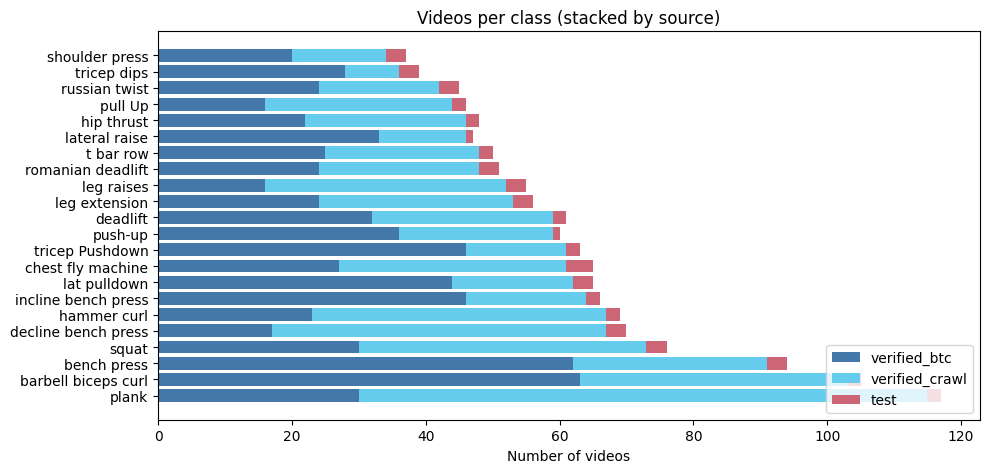

In [9]:
counts = df.groupby(["class", "source"]).size().unstack(fill_value=0)
counts["verified_total"] = counts.filter(regex="verified").sum(axis=1)
counts = counts.sort_values("verified_total", ascending=False)
display(counts)

summary = df.groupby("source").size()
display(summary.to_frame("n_videos"))

fig, ax = plt.subplots(figsize=(10, max(4, len(counts) * 0.22)))
bottom = np.zeros(len(counts))
colors = {"verified_btc": "#4477aa", "verified_crawl": "#66ccee", "test": "#cc6677"}
for src in [c for c in ["verified_btc", "verified_crawl", "test"] if c in counts.columns]:
    vals = counts[src].values
    ax.barh(counts.index, vals, left=bottom, label=src, color=colors.get(src, "#888888"))
    bottom = bottom + vals
ax.set_xlabel("Number of videos")
ax.set_title("Videos per class (stacked by source)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Duration, FPS, and native resolution

Summaries and histograms use **`df_eda`**: probed OK, with duration / long-side outliers removed in the previous cell. Missing durations are omitted from the duration histogram.

,duration_sec,fps,width,height,short_side
count,1370.000000,1370.0,1370.000000,1370.000000,1370.0
mean,8.259882,15.0,424.337226,282.818978,256.0
std,3.166409,0.0,69.793603,68.033921,0.0
min,1.133333,15.0,256.000000,256.000000,256.0
25%,5.200000,15.0,454.000000,256.000000,256.0
50%,10.133008,15.0,454.000000,256.000000,256.0
75%,10.133333,15.0,454.000000,256.000000,256.0
max,19.333008,15.0,484.000000,554.000000,256.0


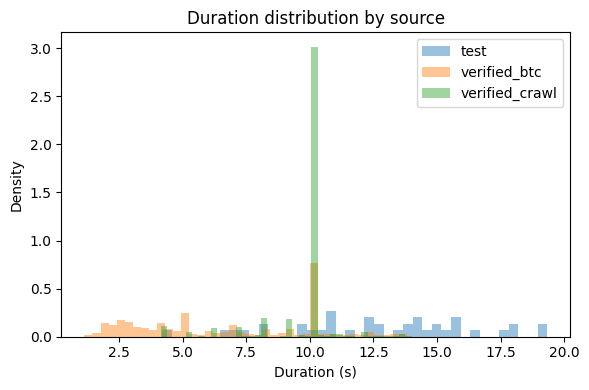

In [11]:
df_ok = df_eda
display(df_ok[["duration_sec", "fps", "width", "height", "short_side"]].describe())

d = df_ok.dropna(subset=["duration_sec"])
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for src, sub in d.groupby("source"):
    ax.hist(sub["duration_sec"], bins=40, alpha=0.45, label=src, density=True)
ax.set_xlabel("Duration (s)")
ax.set_ylabel("Density")
ax.set_title("Duration distribution by source")
ax.legend()
plt.tight_layout()
plt.show()

## Sampled frames (short side ≤ 320, limited frames)

Random **K** videos (fixed seed), **8** frames each, evenly subsampled after decode (cap 400 frames decoded per clip — enough for ~10 s clips).

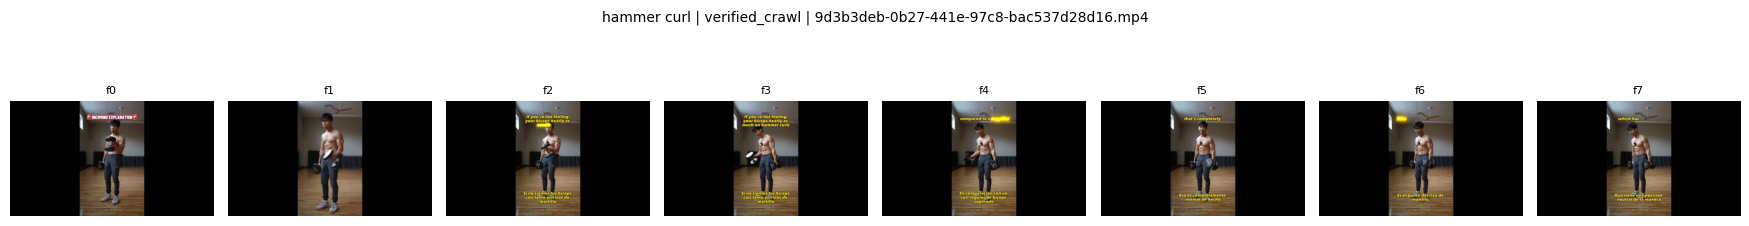

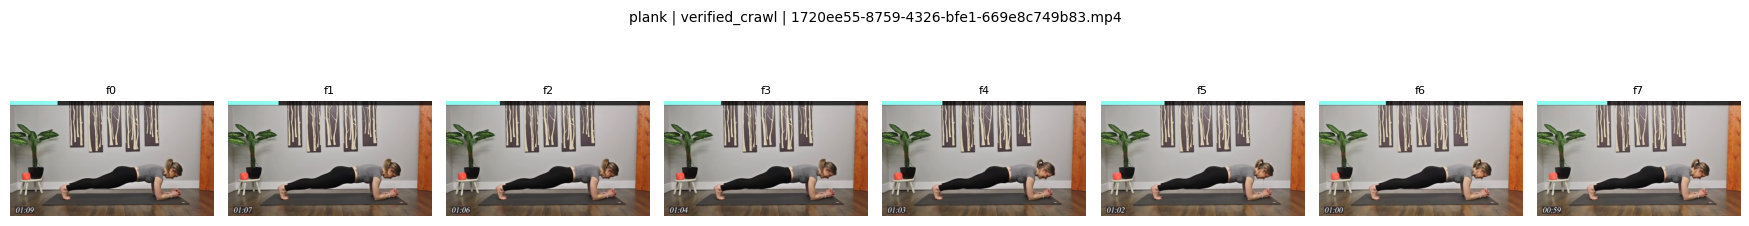

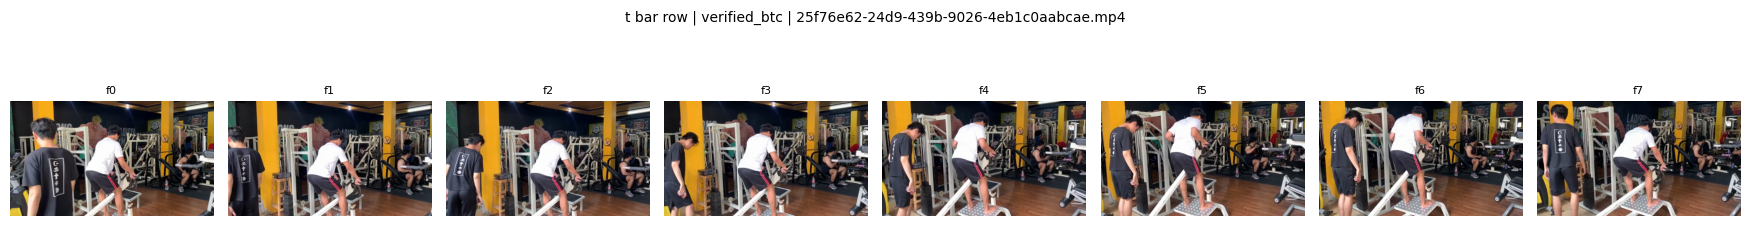

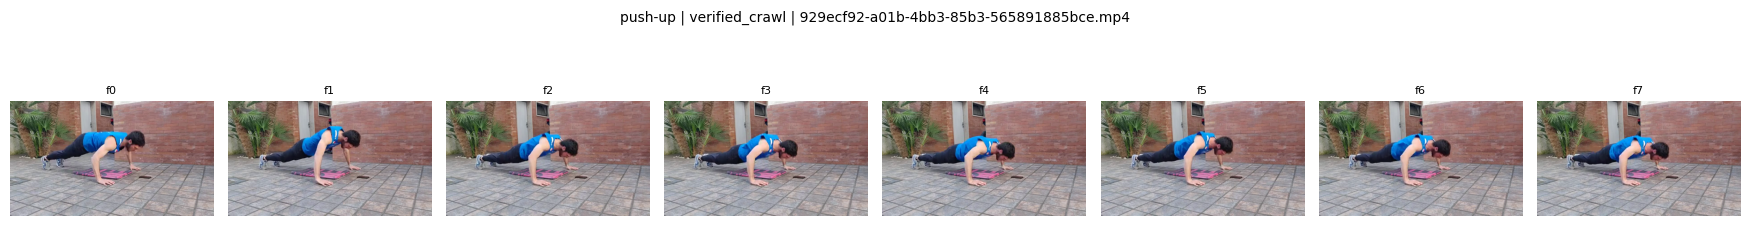

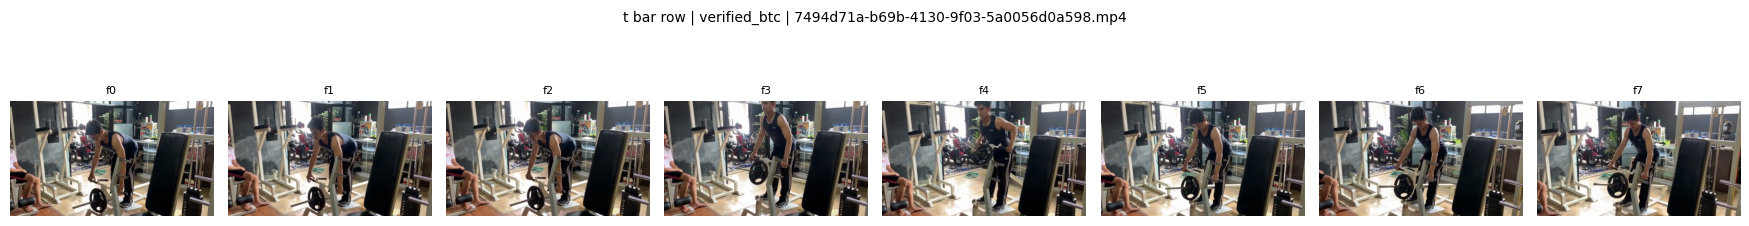

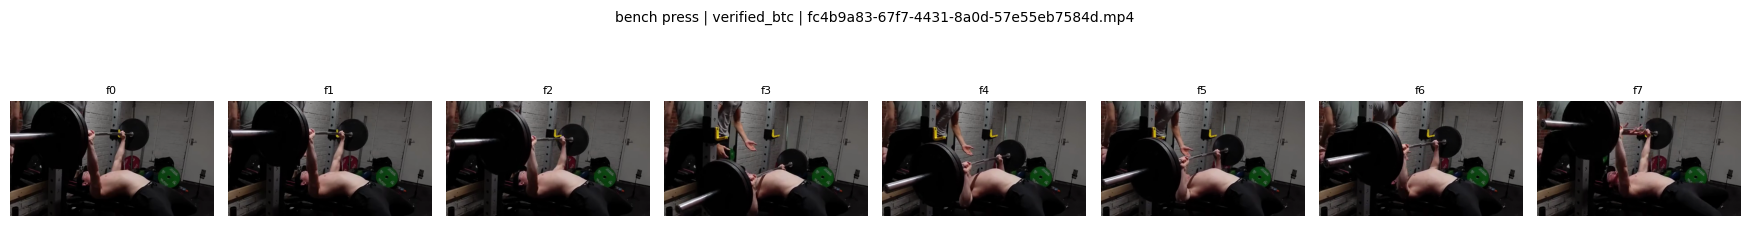

In [12]:
df_ok = df_eda
rng = np.random.default_rng(42)
K = min(6, len(df_ok))
sample_idx = rng.choice(len(df_ok), size=K, replace=False)
sample_rows = df_ok.iloc[sample_idx]

MAX_SHORT = 320
N_FRAMES = 8

for _, row in sample_rows.iterrows():
    p = Path(row["path"])
    frames = decode_sample_frames(p, max_short_side=MAX_SHORT, max_frames=N_FRAMES)
    if not frames:
        print("No frames:", p)
        continue
    n = len(frames)
    fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.8))
    if n == 1:
        axes = [axes]
    title = f"{row['class']} | {row['source']} | {p.name}"
    fig.suptitle(title, fontsize=10)
    for ax, fr, j in zip(axes, frames, range(n)):
        ax.imshow(fr)
        ax.set_axis_off()
        ax.set_title(f"f{j}", fontsize=8)
    plt.tight_layout()
    plt.show()